In [1]:
from data import load_mri_dataframe, get_dataloaders

In [2]:
df = load_mri_dataframe()

train_loader, val_loader = get_dataloaders(df, omit_empty_masks=True)

[Data] Train images: 1093 ; Val images: 280


In [3]:
import torch
import torch.nn as nn

In [4]:
class BaselineUNet0(nn.Module):
    def __init__(self):
        super().__init__()
        num_classes = 1
        # Encoder
        self.enc1 = nn.Sequential(nn.Conv2d(3, 16, 3, padding=1), nn.ReLU())
        self.pool1 = nn.MaxPool2d(2)  # 128x128

        self.enc2 = nn.Sequential(nn.Conv2d(16, 32, 3, padding=1), nn.ReLU())
        self.pool2 = nn.MaxPool2d(2)  # 64x64

        # Bottleneck
        self.bottleneck = nn.Sequential(nn.Conv2d(32, 64, 3, padding=1), nn.ReLU())

        # Decoder
        self.up2 = nn.ConvTranspose2d(64, 32, 2, stride=2)  # 64x64
        self.dec2 = nn.Sequential(nn.Conv2d(64, 32, 3, padding=1), nn.ReLU())

        self.up1 = nn.ConvTranspose2d(32, 16, 2, stride=2)  # 128x128
        self.dec1 = nn.Sequential(nn.Conv2d(32, 16, 3, padding=1), nn.ReLU())

        # Final
        self.final = nn.Conv2d(16, num_classes, kernel_size=1)

    def forward(self, x):
        e1 = self.enc1(x)
        p1 = self.pool1(e1)

        e2 = self.enc2(p1)
        p2 = self.pool2(e2)

        b = self.bottleneck(p2)

        u2 = self.up2(b)
        d2 = self.dec2(torch.cat([u2, e2], dim=1))

        u1 = self.up1(d2)
        d1 = self.dec1(torch.cat([u1, e1], dim=1))

        return self.final(d1)


[I 2025-06-19 20:55:52,880] A new study created in memory with name: no-name-3e193ac6-ad07-4503-86a4-492ddd3b21be


[Data] Train images: 1093 ; Val images: 280


[I 2025-06-19 20:58:22,465] Trial 0 finished with value: 0.5092487947808372 and parameters: {'lr': 0.00026518856631686165, 'batch_size': 16, 'optimizer': 'Adam', 'num_layers': 4, 'num_filters': 8, 'step_size': 6, 'gamma': 0.41708421641709903}. Best is trial 0 with value: 0.5092487947808372.


Stopped early at epoch 49!
[Data] Train images: 1093 ; Val images: 280


[I 2025-06-19 20:59:23,049] Trial 1 finished with value: 0.05820896604231426 and parameters: {'lr': 1.0086374349928028e-05, 'batch_size': 8, 'optimizer': 'SGD', 'num_layers': 2, 'num_filters': 16, 'step_size': 4, 'gamma': 0.24986059725848375}. Best is trial 0 with value: 0.5092487947808372.


...

[I 2025-06-19 23:31:38,255] Trial 28 finished with value: 0.6112181774207524 and parameters: {'lr': 0.0001402756464639942, 'batch_size': 8, 'optimizer': 'Adam', 'num_layers': 5, 'num_filters': 16, 'step_size': 6, 'gamma': 0.4991957608427042}. Best is trial 15 with value: 0.7969783743222555.


Stopped early at epoch 35!
[Data] Train images: 1093 ; Val images: 280


[I 2025-06-19 23:38:32,125] Trial 29 finished with value: 0.7852331161499023 and parameters: {'lr': 0.00031818965651346016, 'batch_size': 4, 'optimizer': 'Adam', 'num_layers': 4, 'num_filters': 32, 'step_size': 7, 'gamma': 0.420547041781101}. Best is trial 15 with value: 0.7969783743222555.


Stopped early at epoch 41!
Best hyperparameters: {'lr': 0.0011353688880912437, 'batch_size': 16, 'optimizer': 'Adam', 'num_layers': 5, 'num_filters': 32, 'step_size': 6, 'gamma': 0.49413457378264336}


Stopped early at epoch 40!
Final Val Dice: 0.8028
Final Val IoU : 0.7152


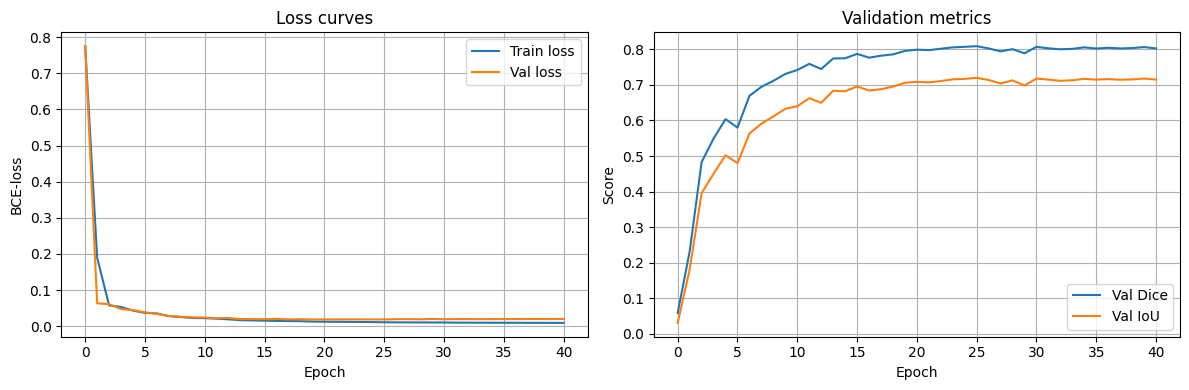

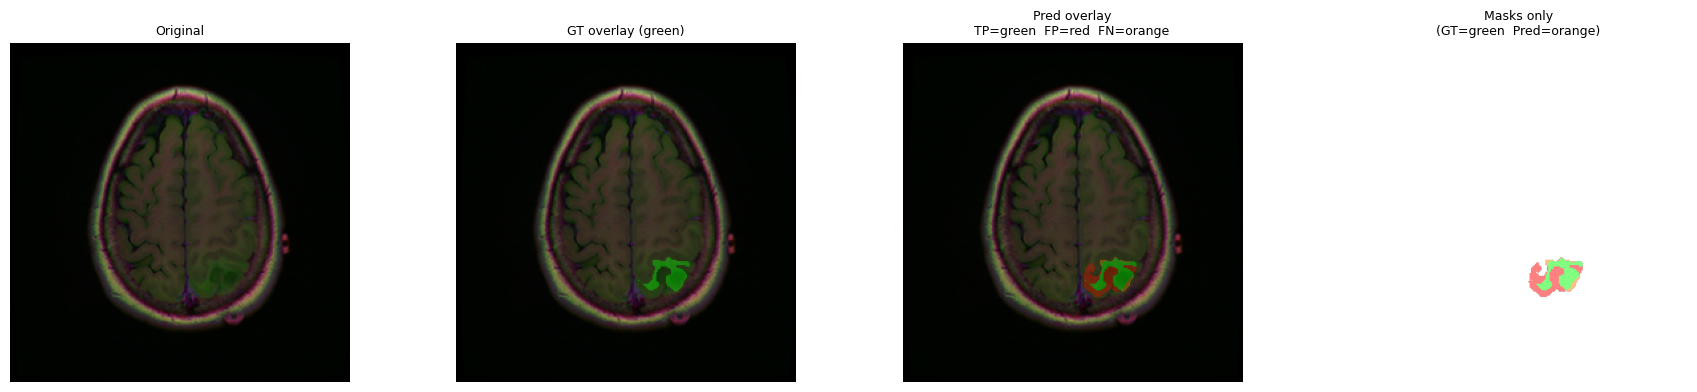

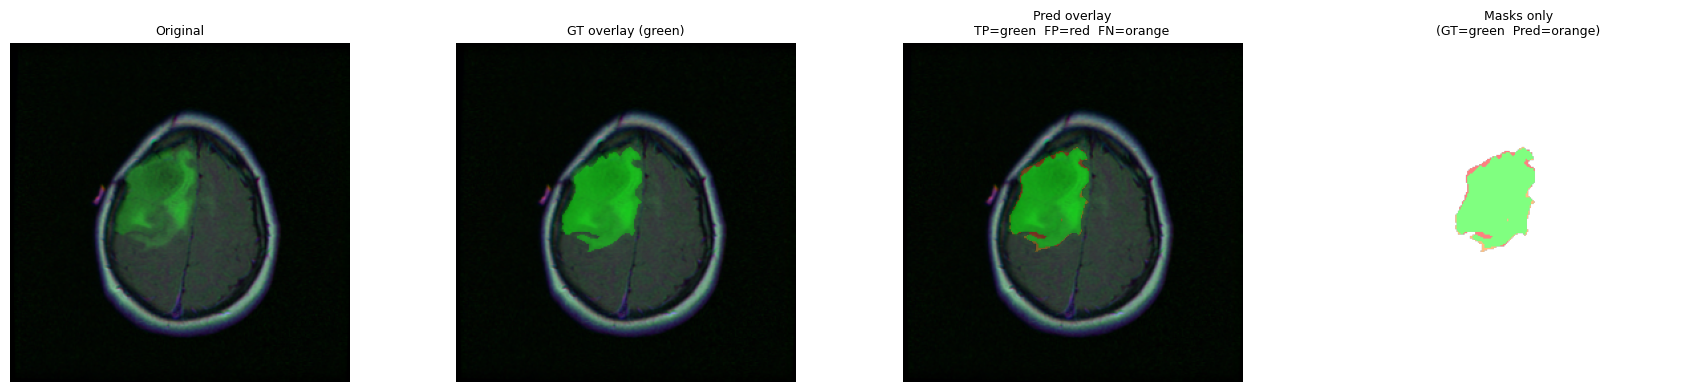

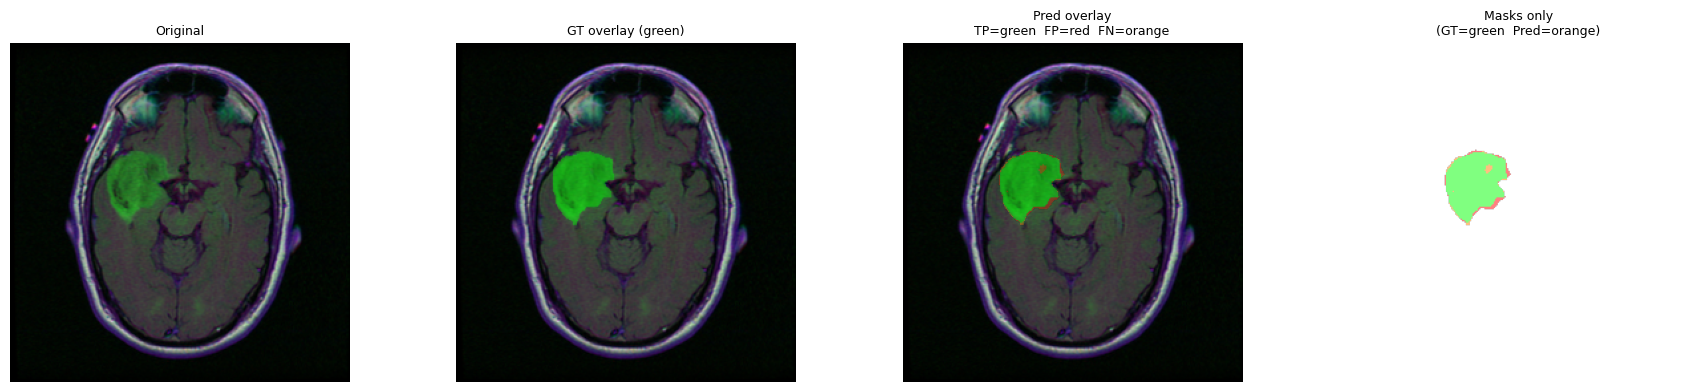

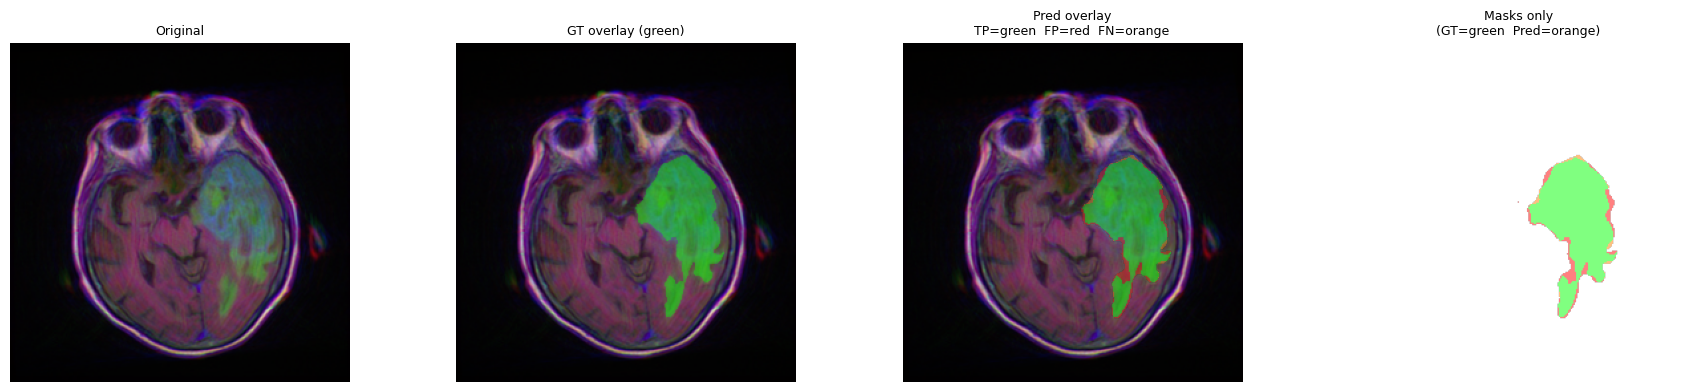

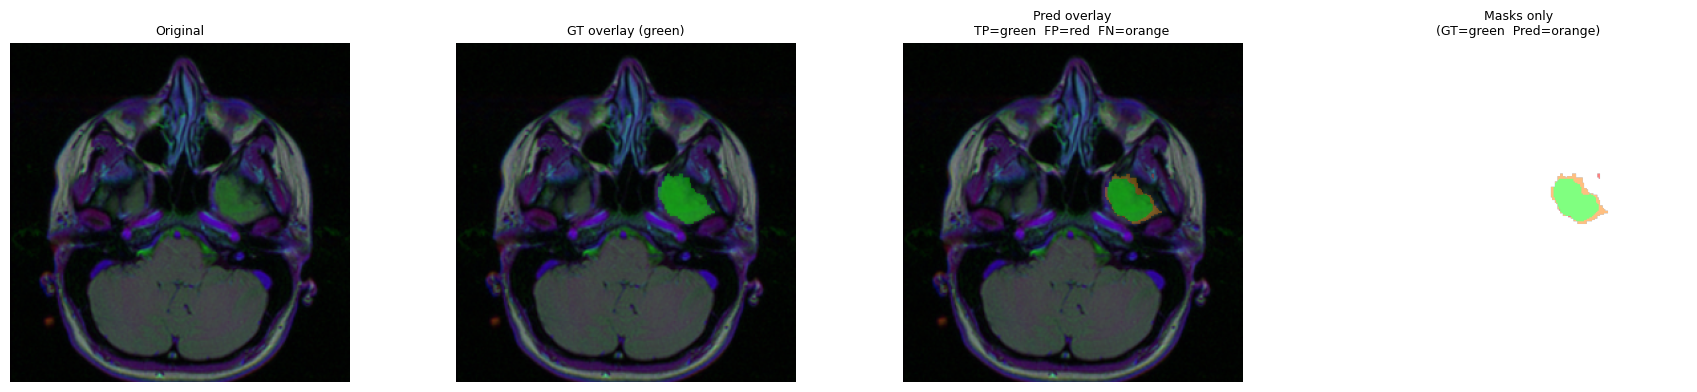

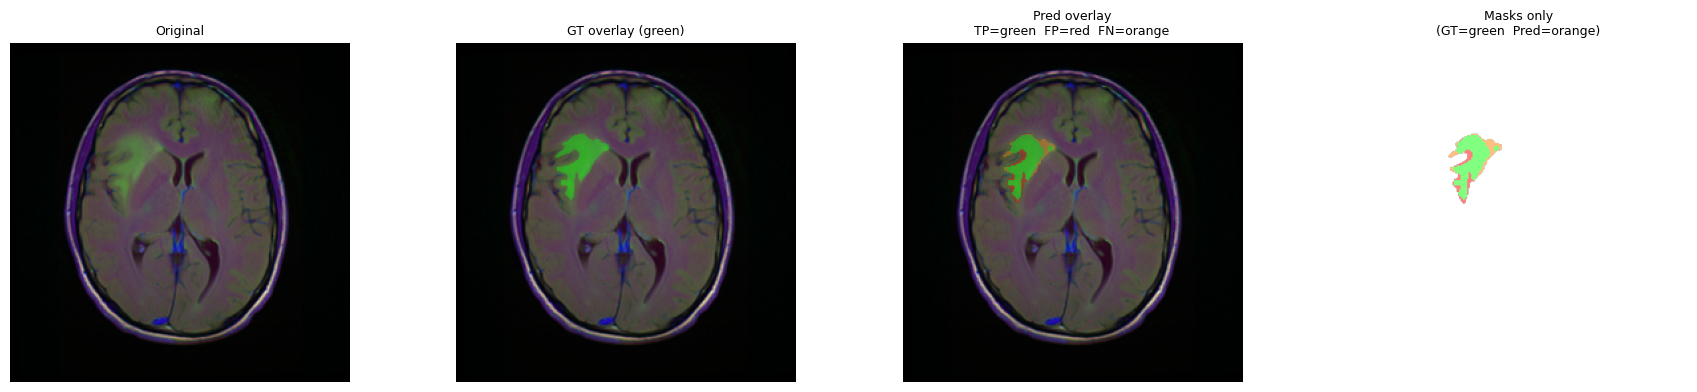

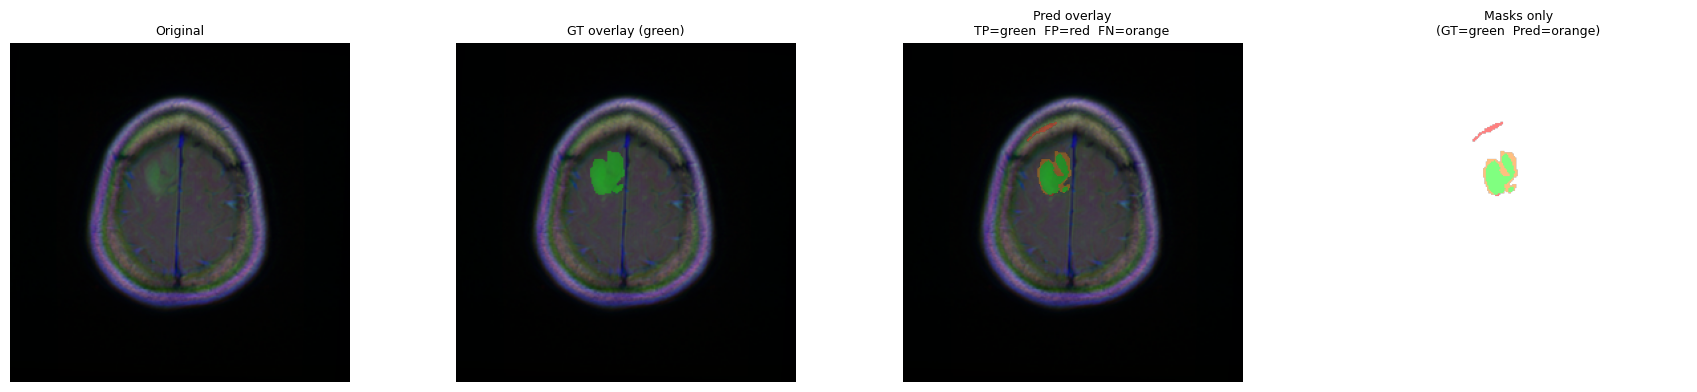

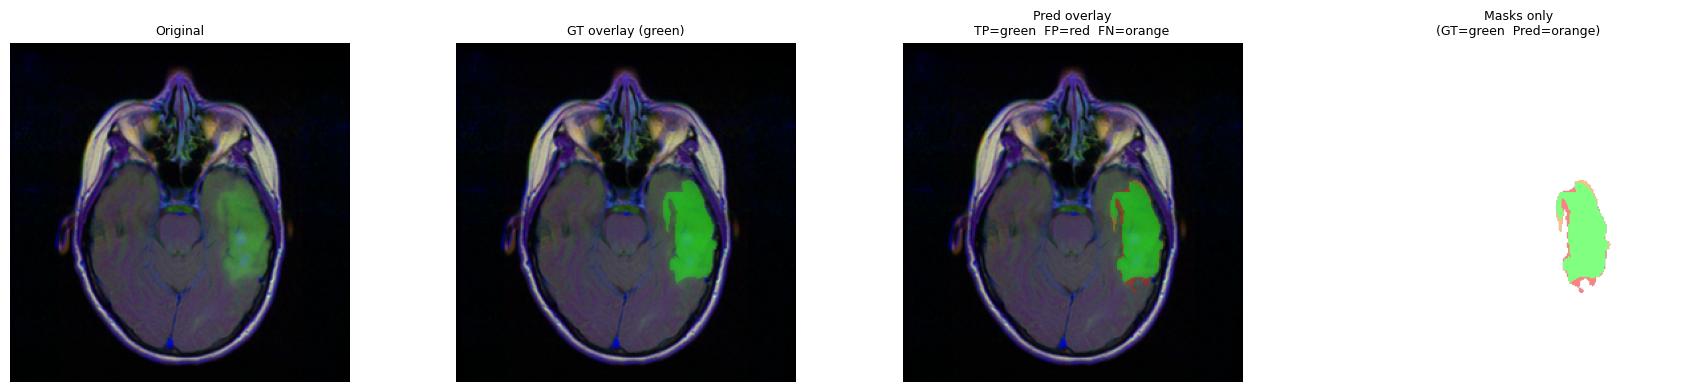

In [5]:
from train_generalized_earlystopping import train, dice_loss, bce_loss, bce_dice_loss, focal_loss, tversky_loss
from eval import evaluate, evaluate_losses, evaluate_classification
from hyperparameter_search import create_study
from BaselineUNetParams import BaselineUNet
import torch.optim as optim


study = create_study(n_trials=30)
params = study.best_params
print("Best hyperparameters:", params)

if params['optimizer'] == "Adam":
    optimizer_class = optim.Adam
else:
    optimizer_class = optim.SGD

model = BaselineUNet(num_layers=params['num_layers'], num_filters=params['num_filters'])
device = torch.device('cuda')
trained_model, results_bce = train(
        model,
        train_loader,
        val_loader,
        device,
        lr=params['lr'],
        optimizer_class=optimizer_class,
        loss_fn=bce_loss,
        epochs=100,
        lr_sched_cls=torch.optim.lr_scheduler.StepLR,
        lr_sched_kwargs={"step_size": params['step_size'], "gamma": params['gamma']},
    )

evaluate(results_bce)

Stopped early at epoch 15!
Final Val Dice: 0.0000
Final Val IoU : 0.0000


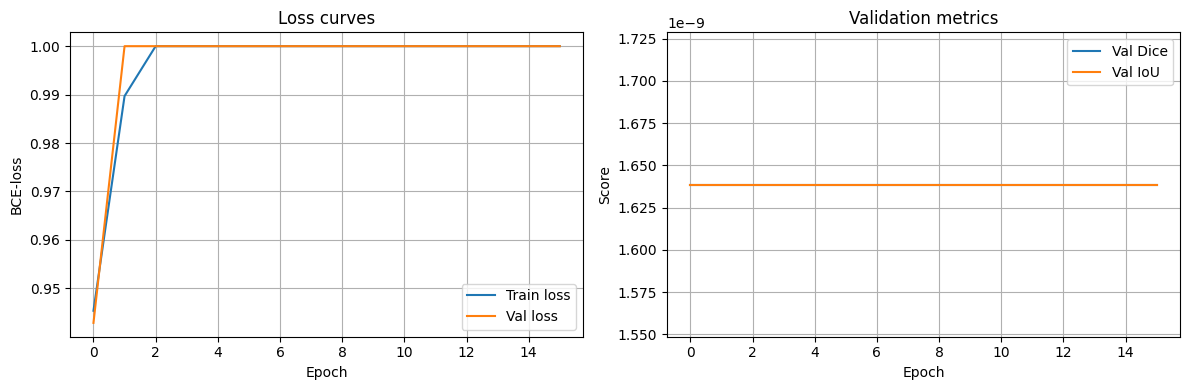

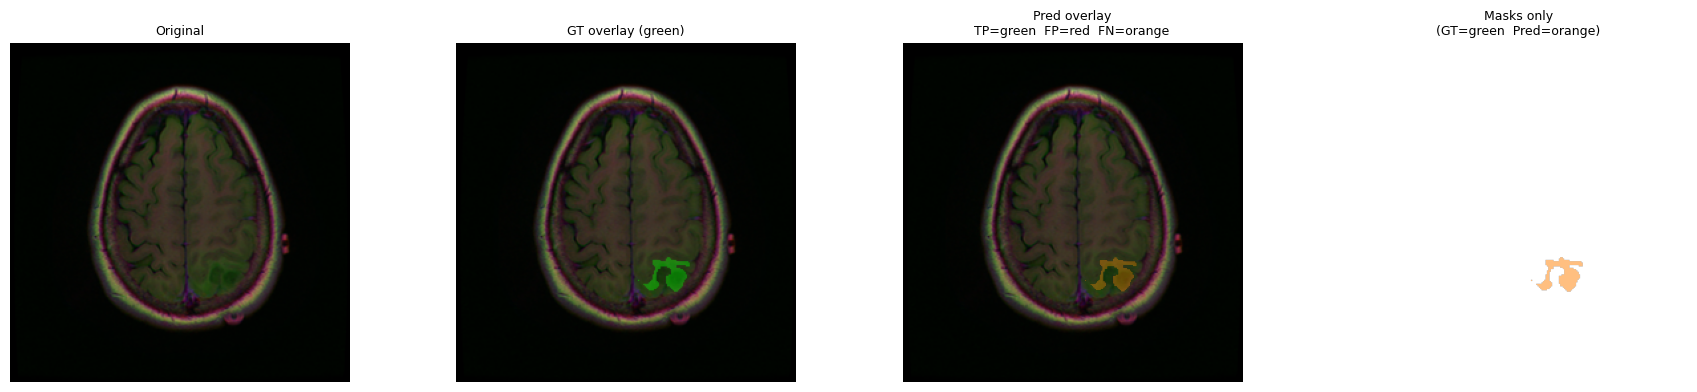

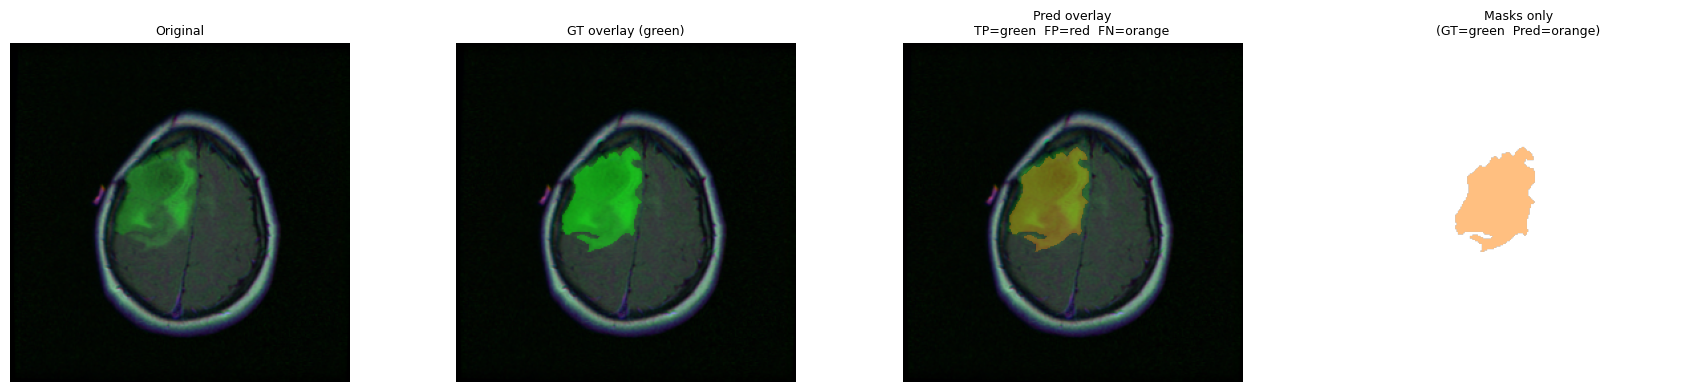

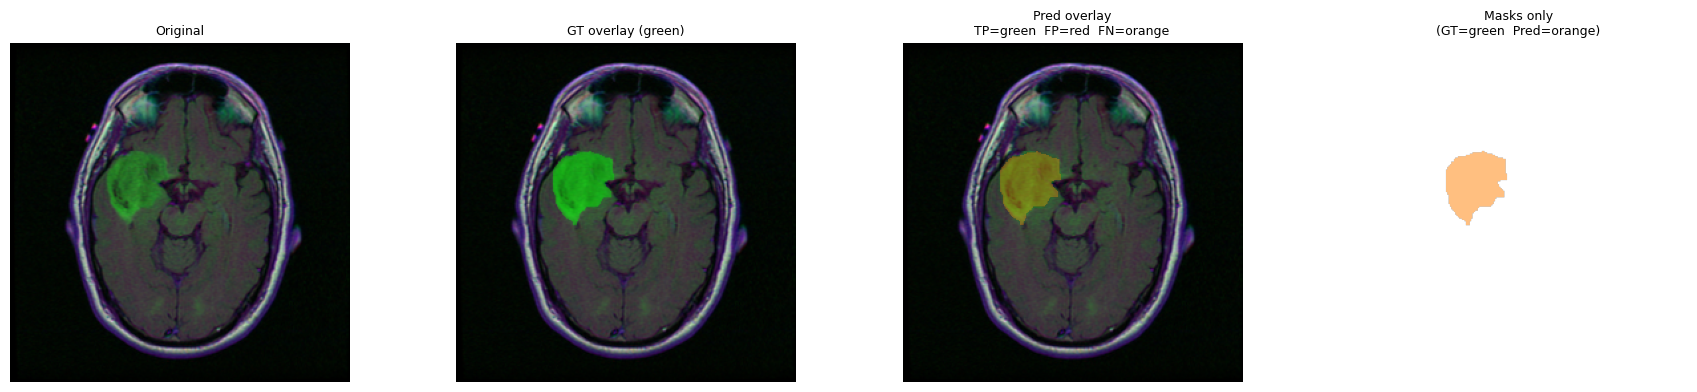

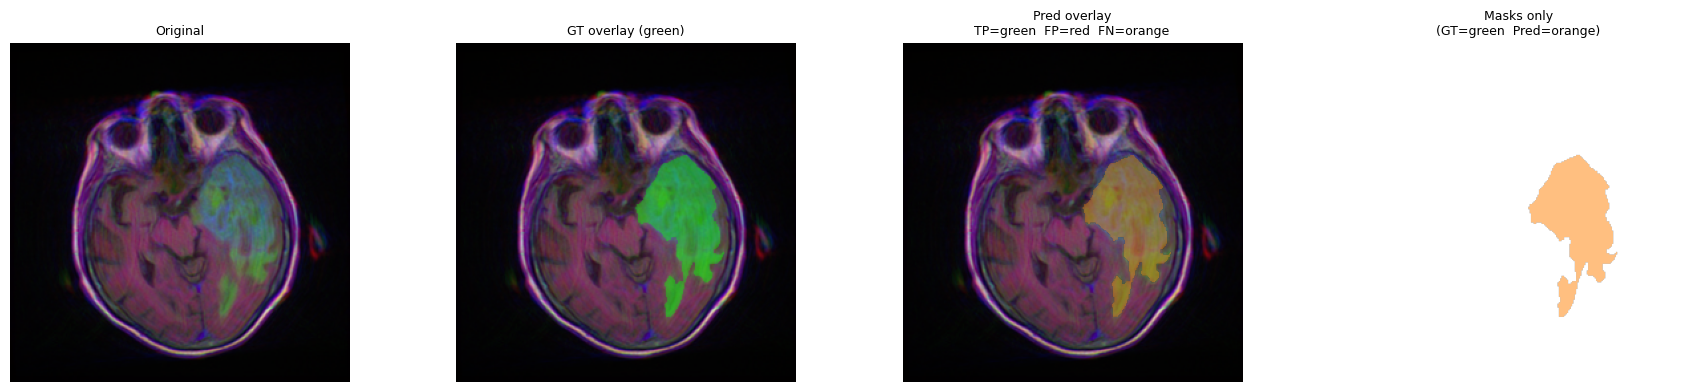

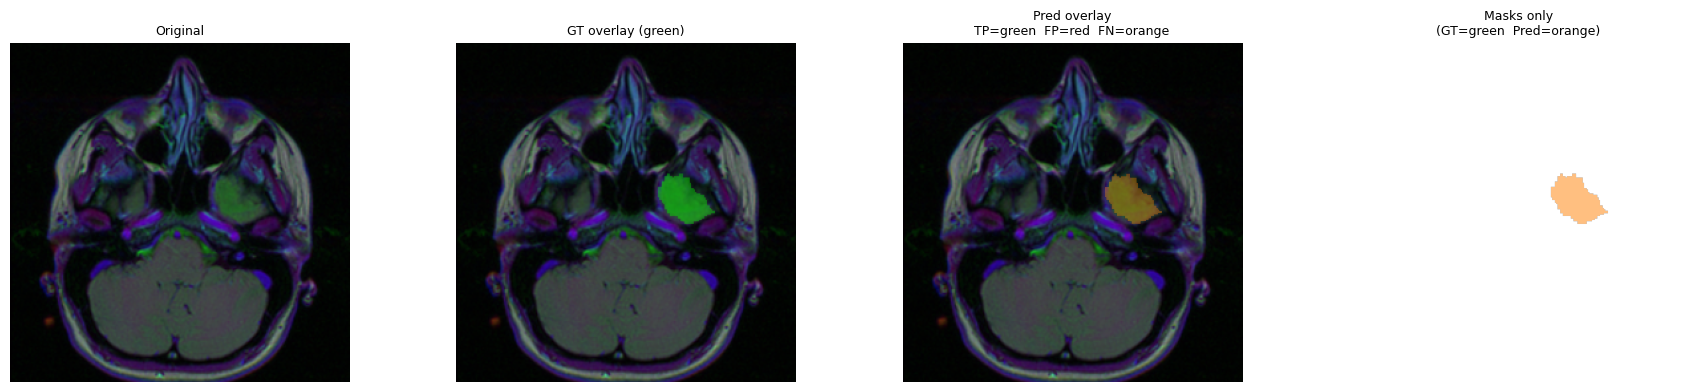

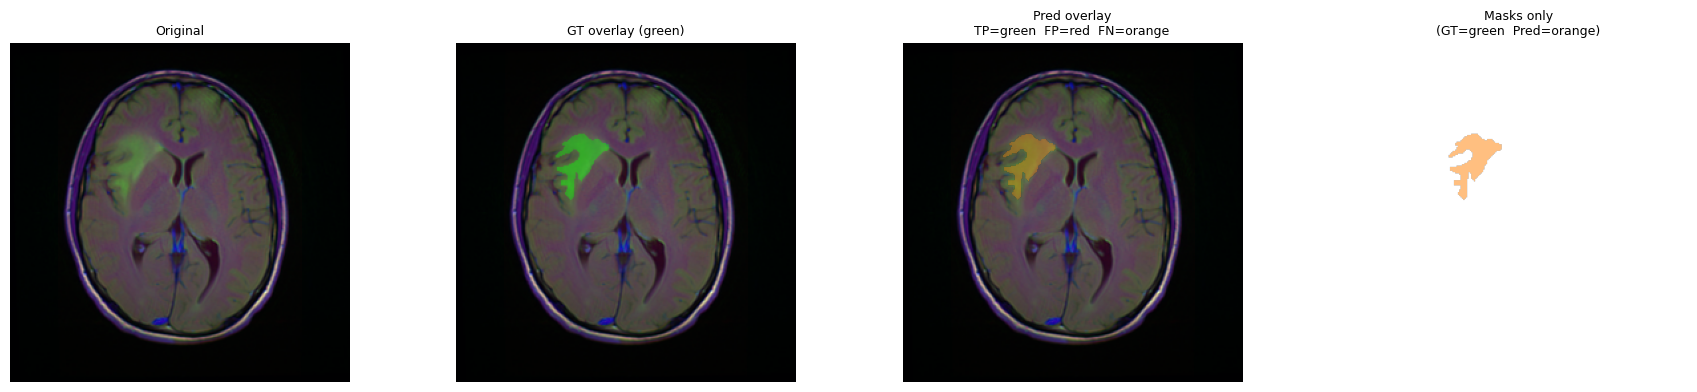

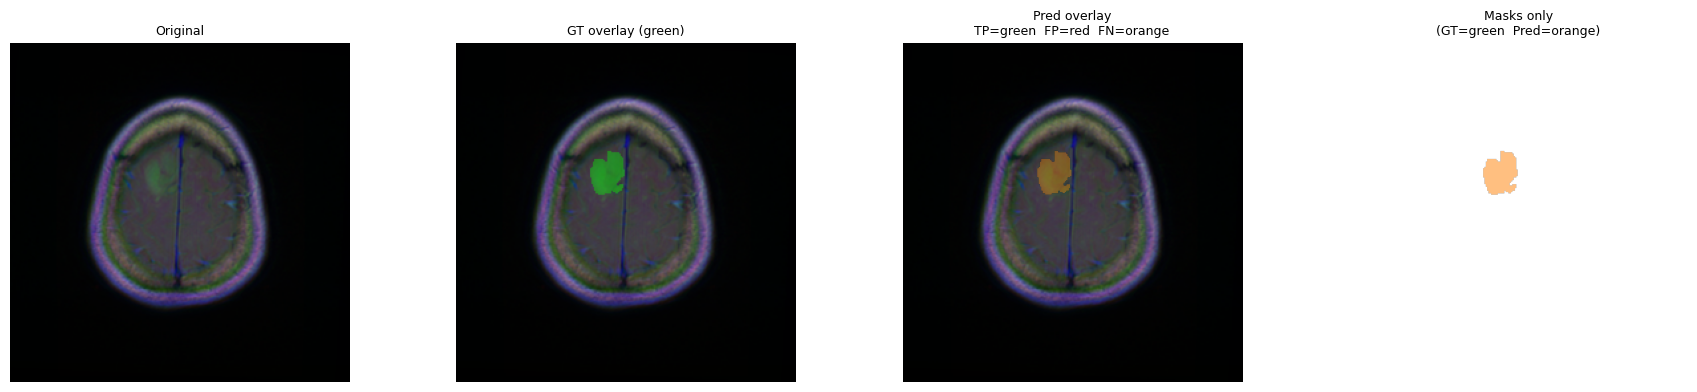

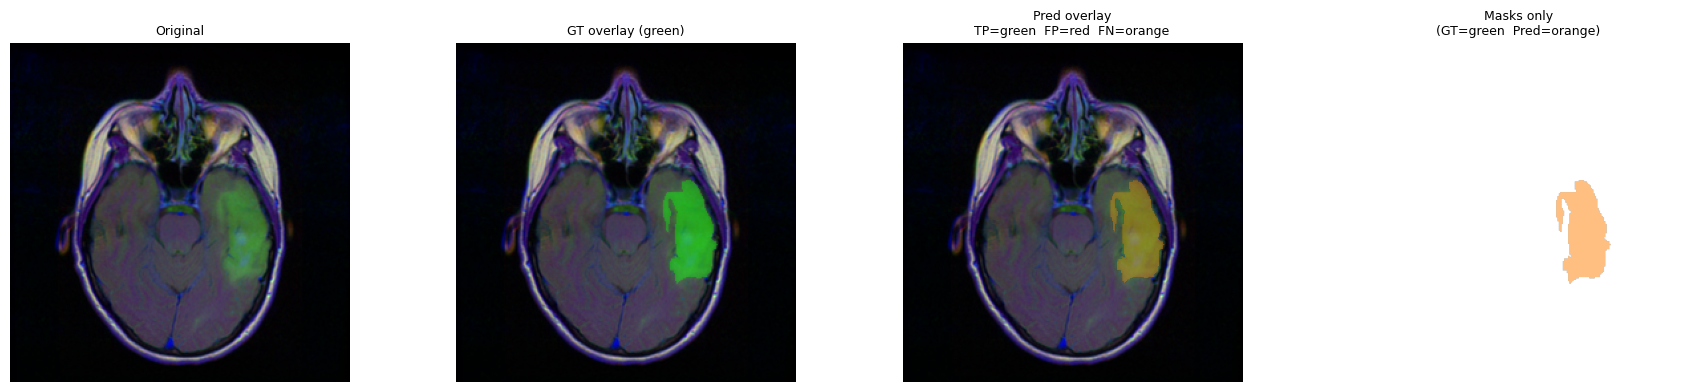

In [6]:
model = BaselineUNet(num_layers=params['num_layers'], num_filters=params['num_filters'])
device = torch.device('cuda')

trained_model, results_dice = train(
        model,
        train_loader,
        val_loader,
        device,
        lr=params['lr'],
        optimizer_class=optimizer_class,
        loss_fn=dice_loss,
        epochs=100,
        lr_sched_cls=torch.optim.lr_scheduler.StepLR,
        lr_sched_kwargs={"step_size": params['step_size'], "gamma": params['gamma']},
    )

evaluate(results_dice)

Stopped early at epoch 53!
Final Val Dice: 0.6445
Final Val IoU : 0.5420


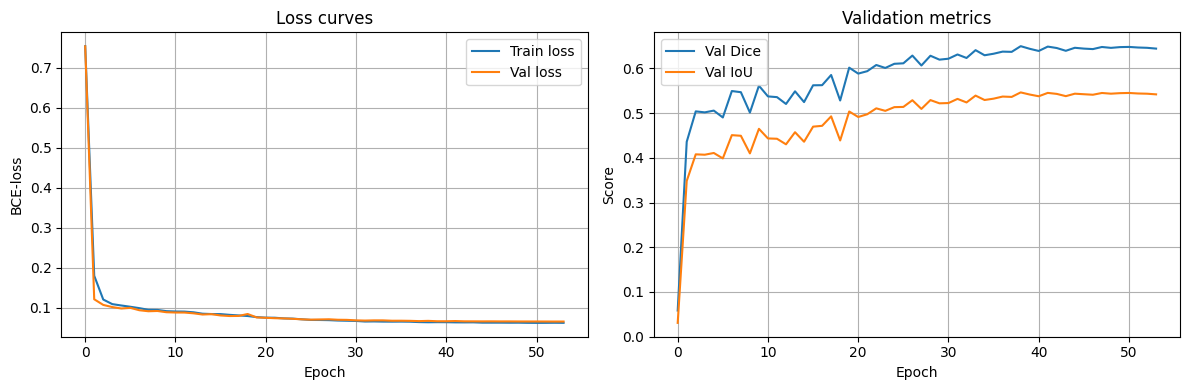

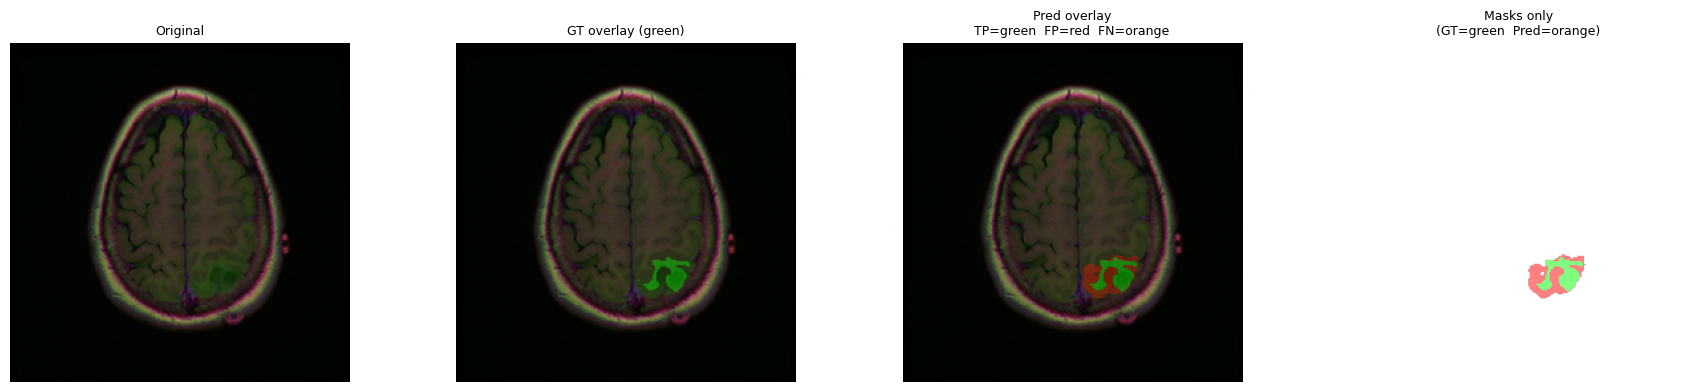

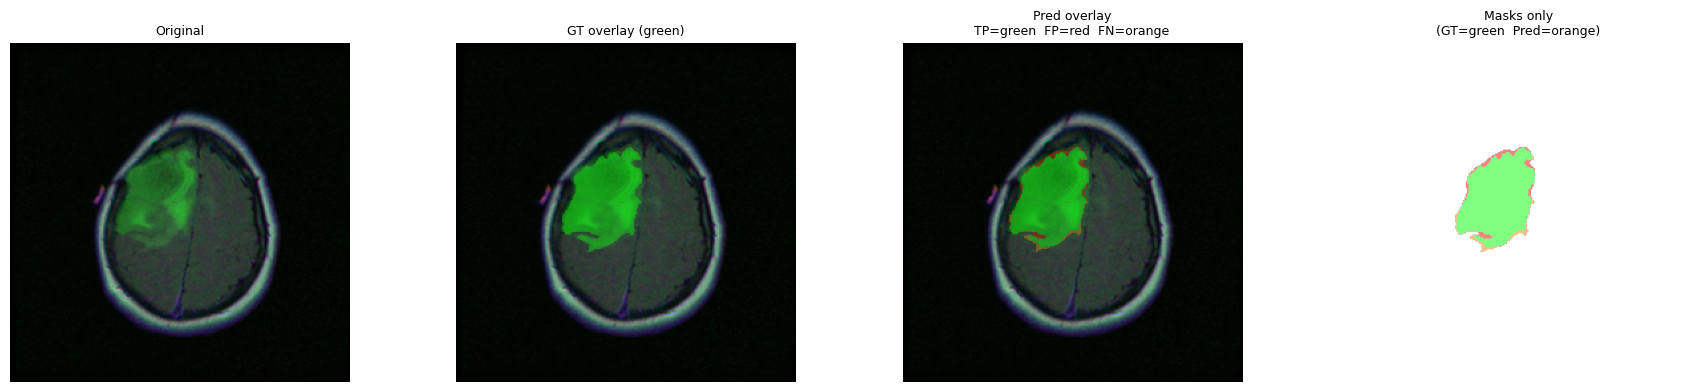

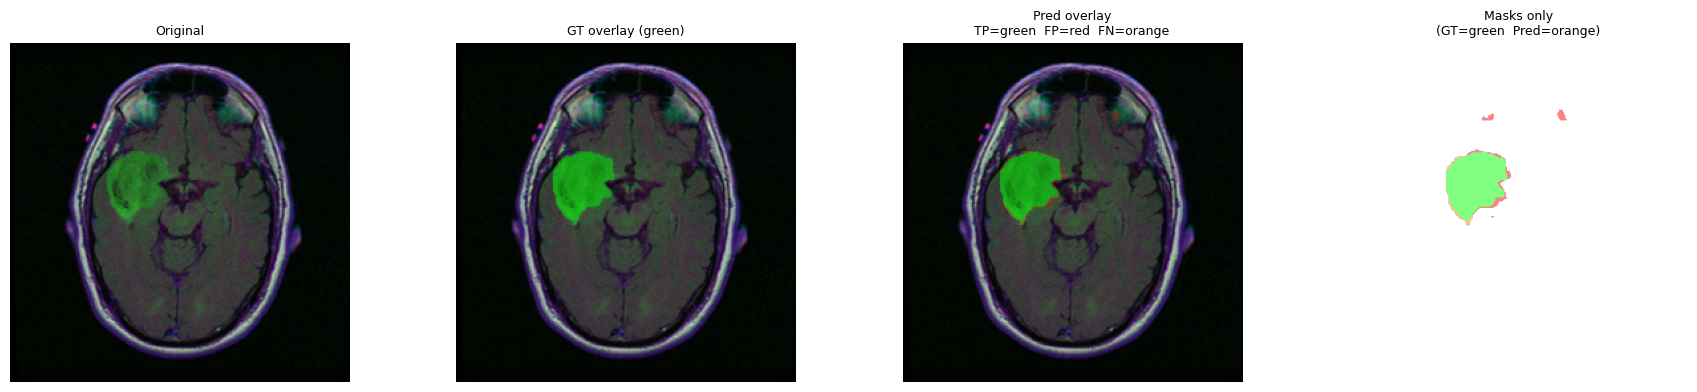

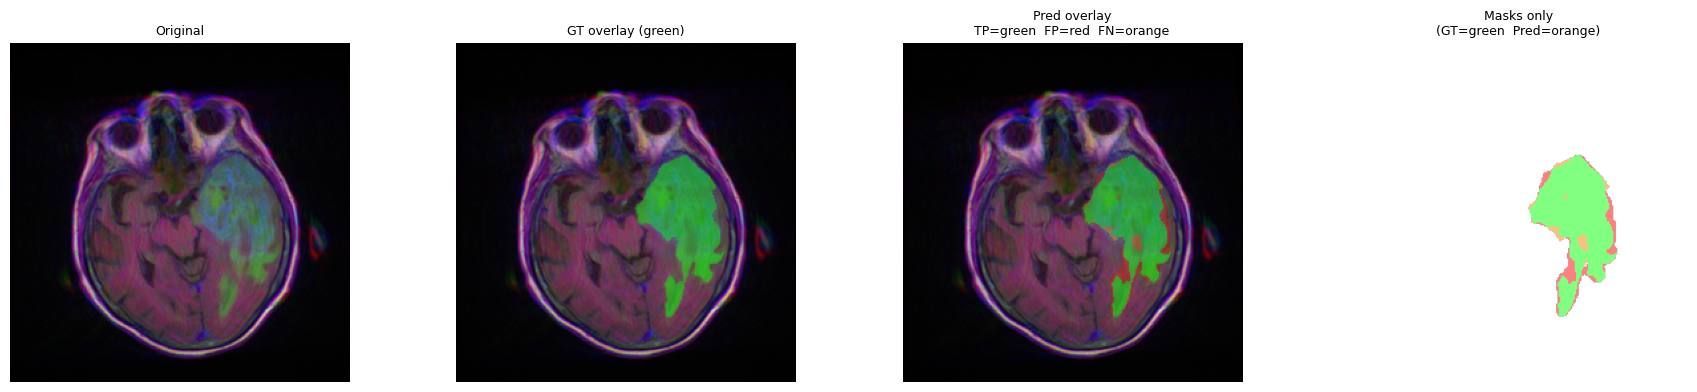

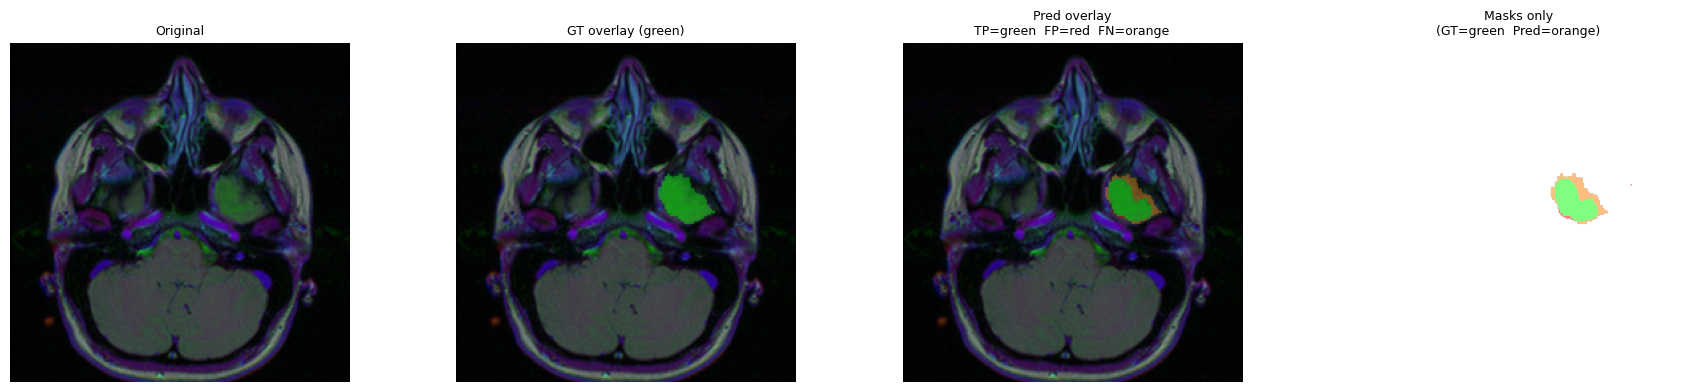

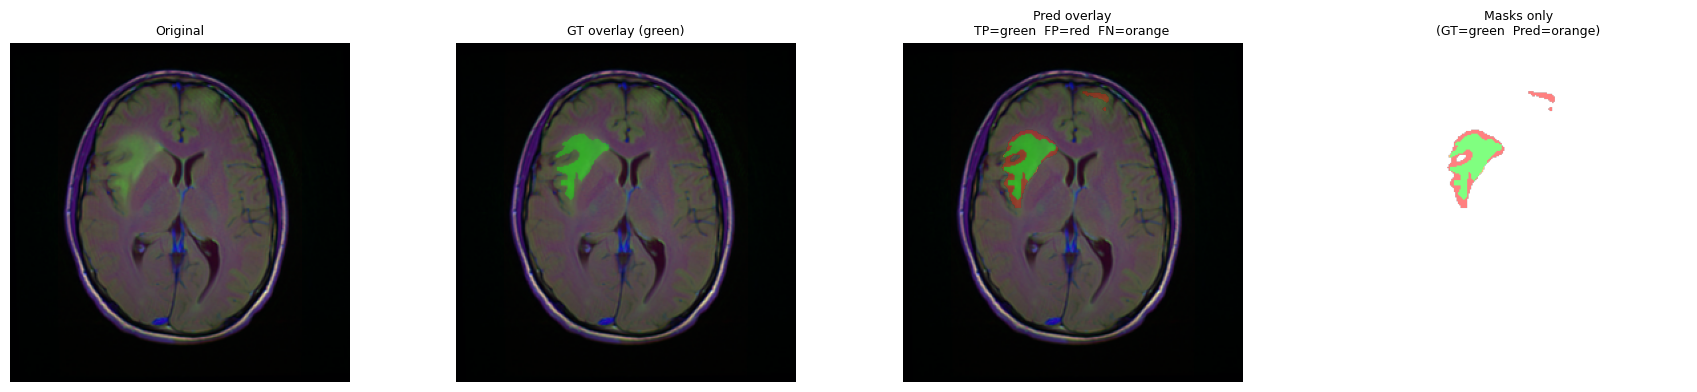

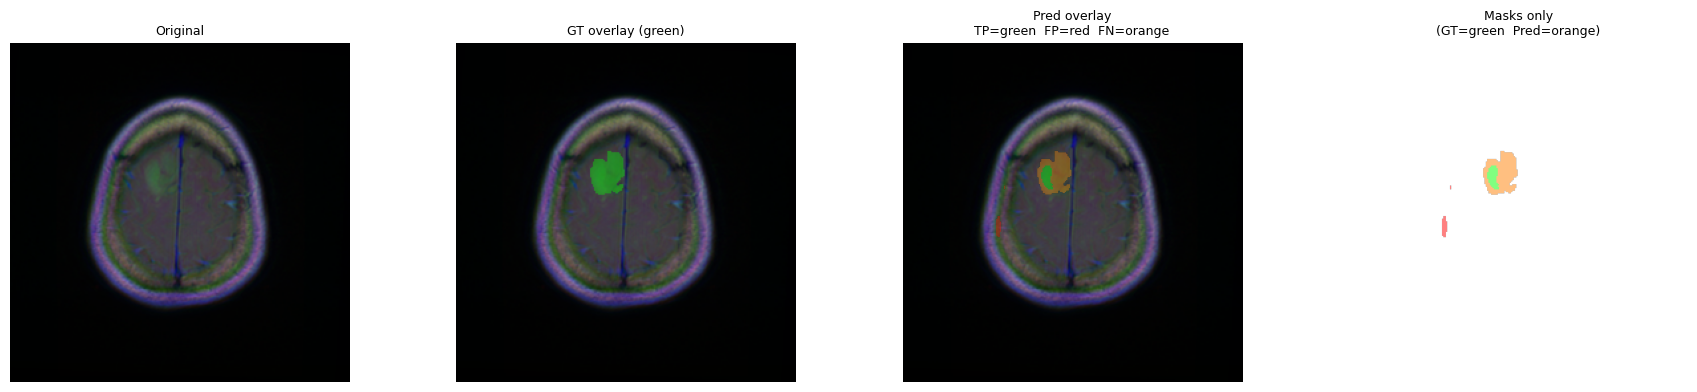

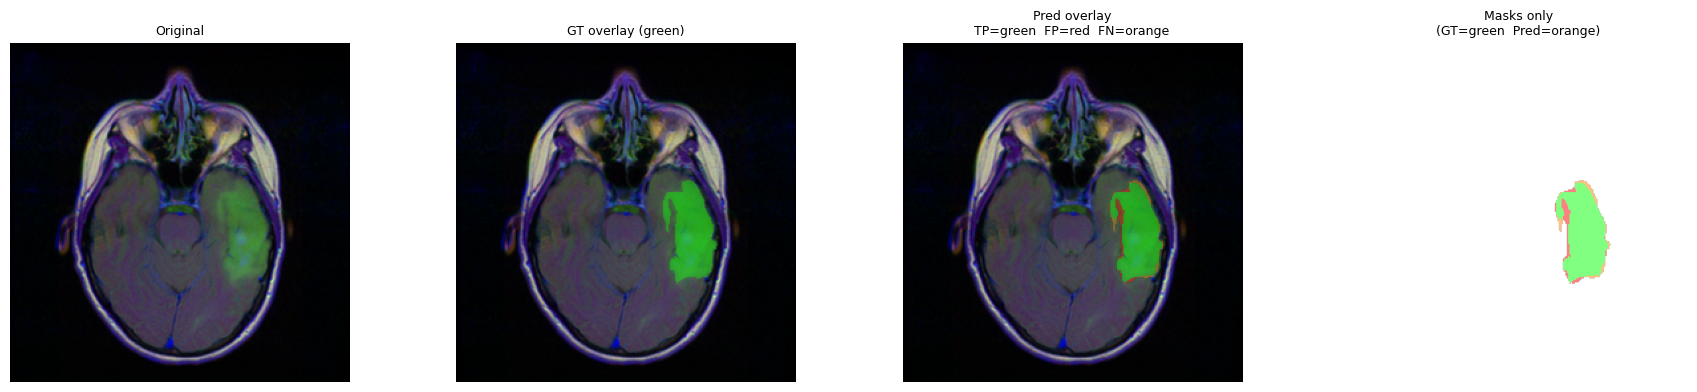

In [7]:
model = BaselineUNet(num_layers=params['num_layers'], num_filters=params['num_filters'])
device = torch.device('cuda')

trained_model, results_bce_dice = train(
        model,
        train_loader,
        val_loader,
        device,
        lr=params['lr'],
        optimizer_class=optimizer_class,
        loss_fn=bce_dice_loss,
        epochs=100,
        lr_sched_cls=torch.optim.lr_scheduler.StepLR,
        lr_sched_kwargs={"step_size": params['step_size'], "gamma": params['gamma']},
    )

evaluate(results_bce_dice)

Stopped early at epoch 15!
Final Val Dice: 0.0000
Final Val IoU : 0.0000


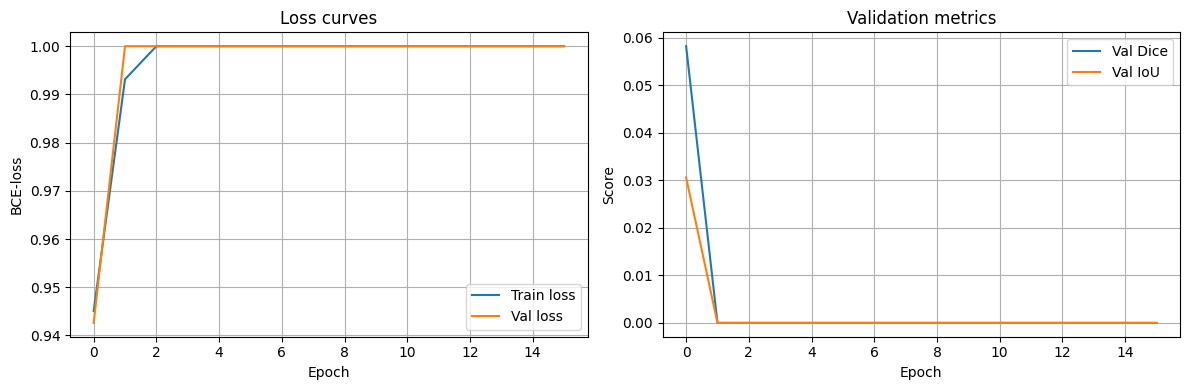

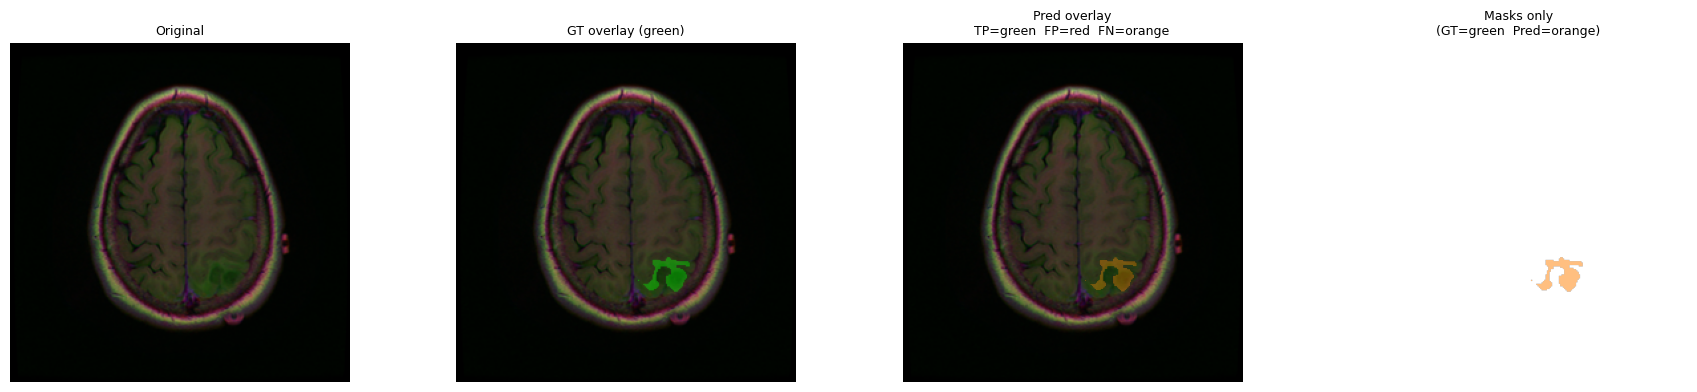

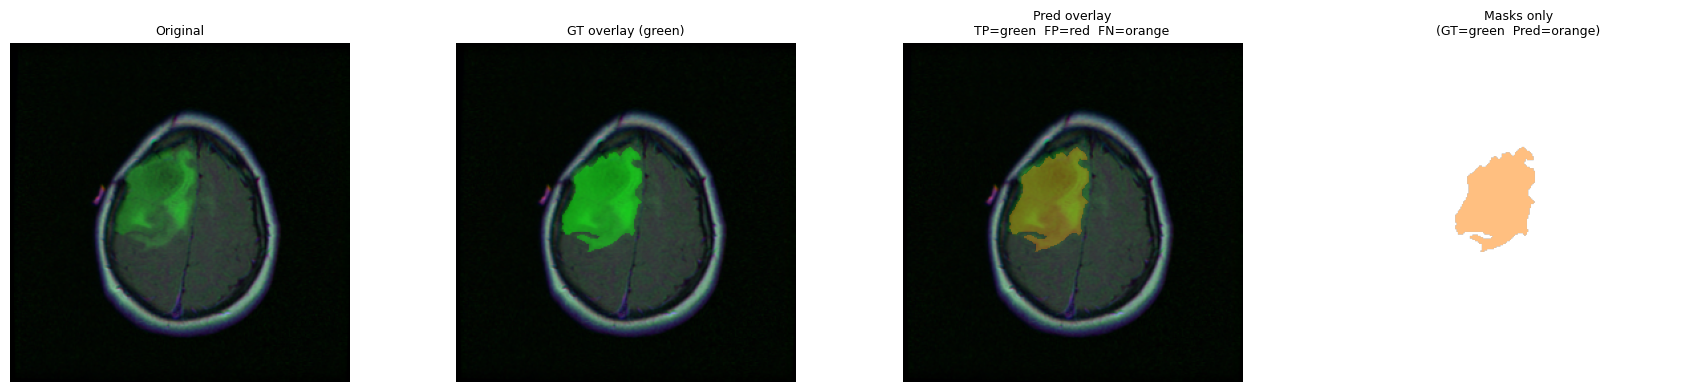

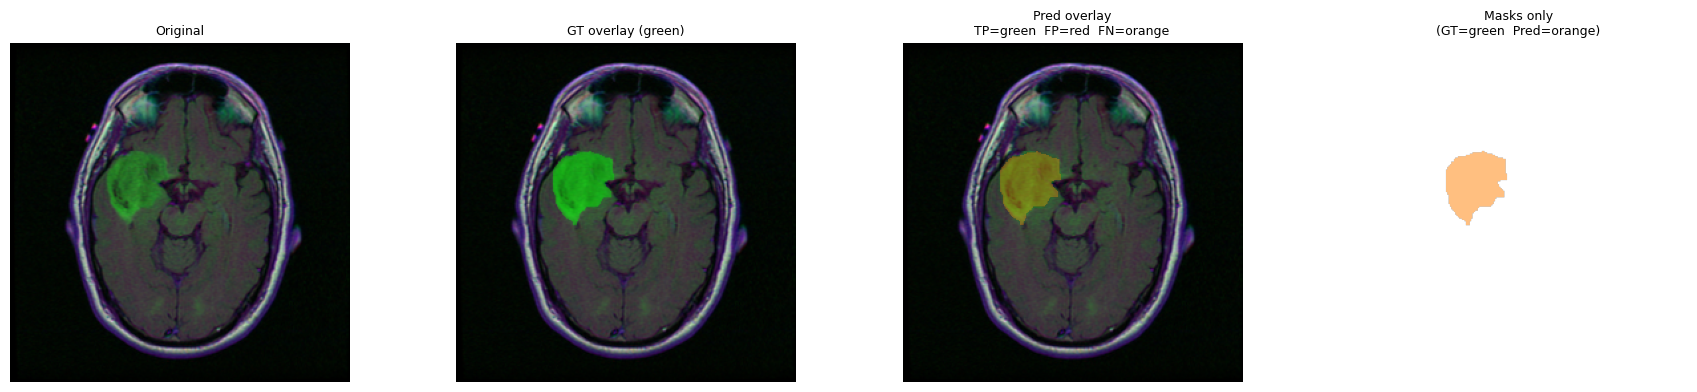

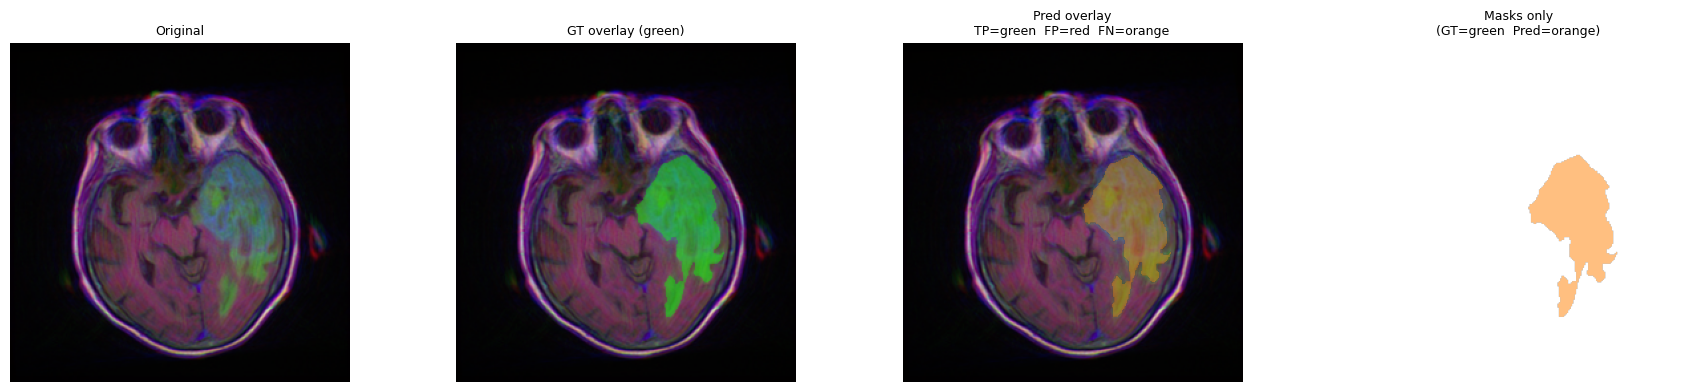

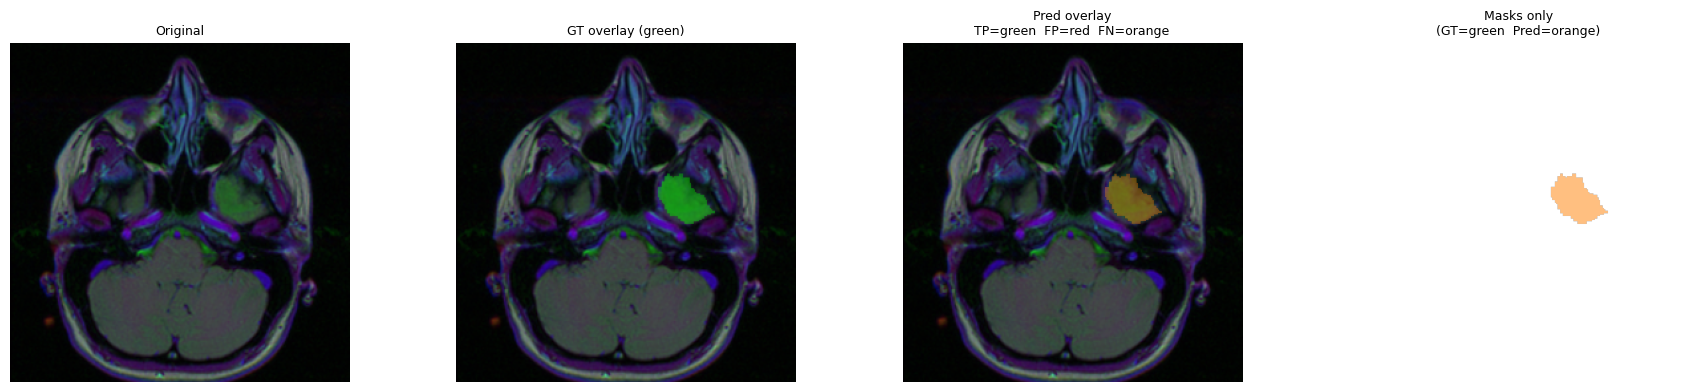

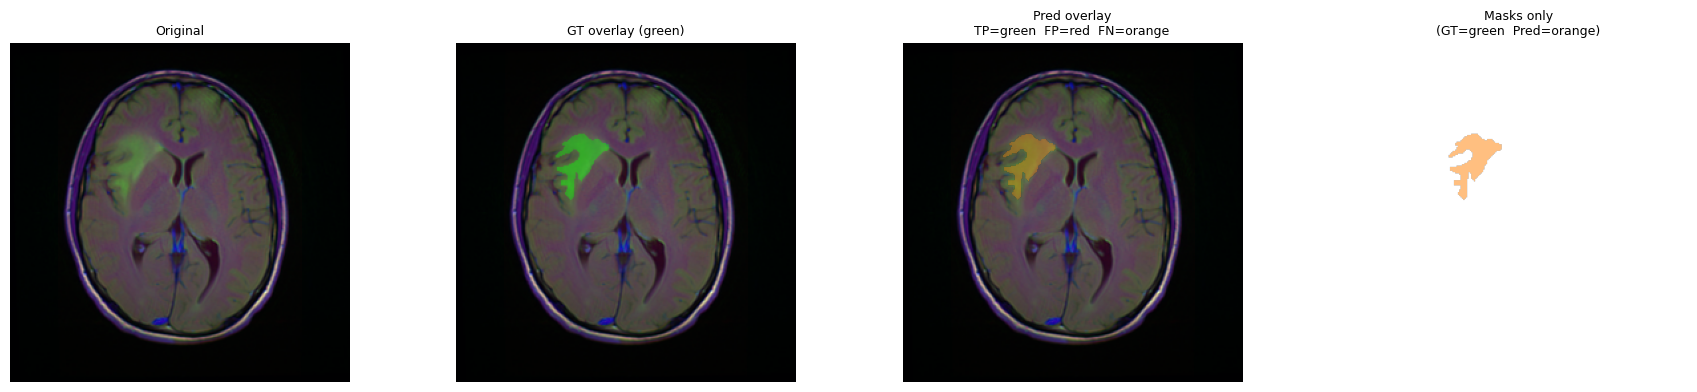

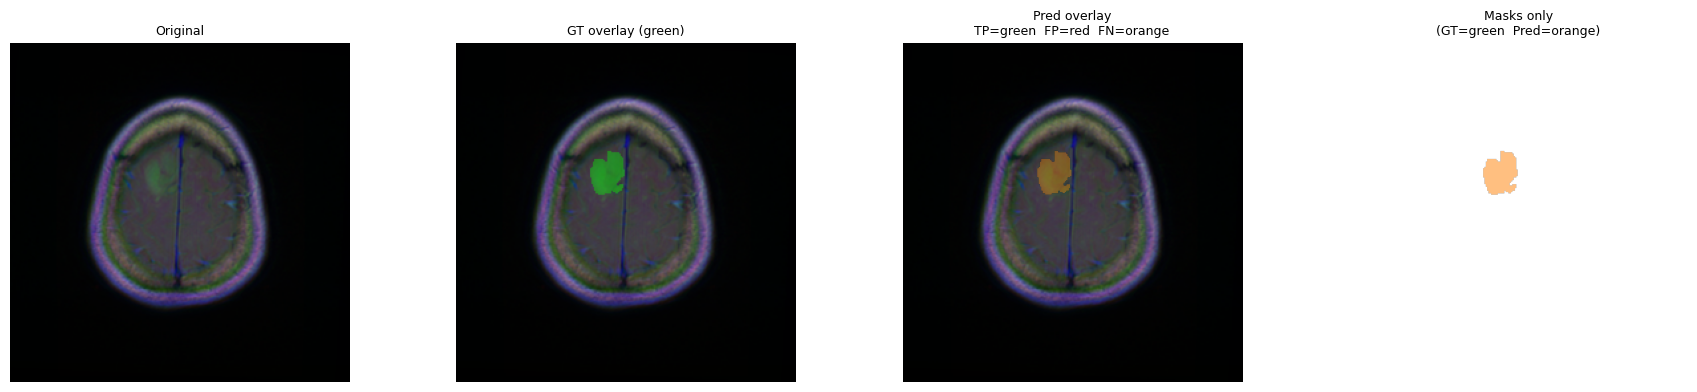

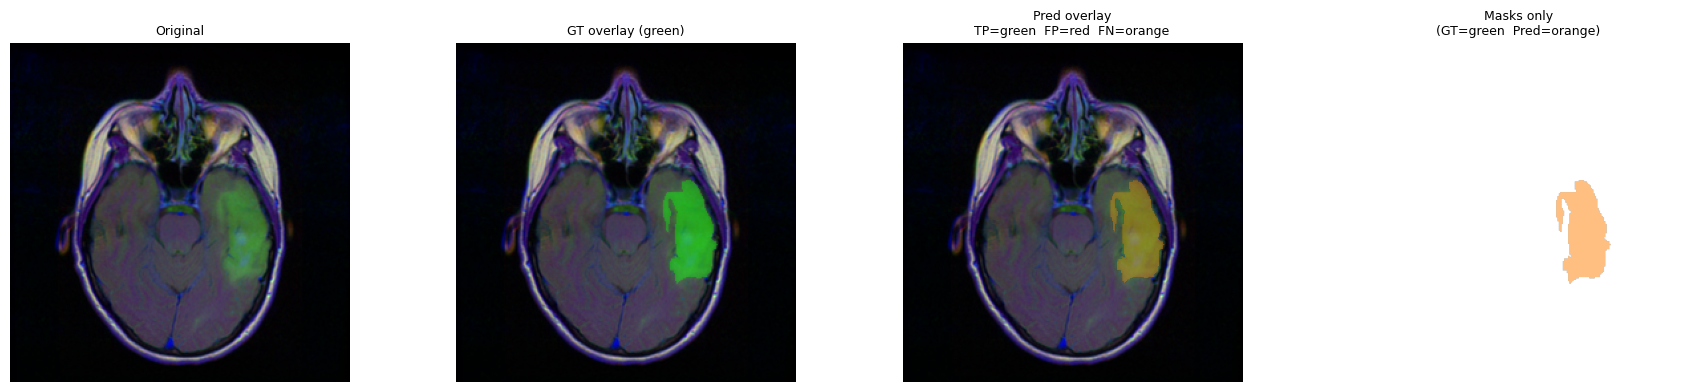

In [8]:
model = BaselineUNet(num_layers=params['num_layers'], num_filters=params['num_filters'])
device = torch.device('cuda')

trained_model, results_tversky = train(
        model,
        train_loader,
        val_loader,
        device,
        lr=params['lr'],
        optimizer_class=optimizer_class,
        loss_fn=tversky_loss,
        epochs=100,
        lr_sched_cls=torch.optim.lr_scheduler.StepLR,
        lr_sched_kwargs={"step_size": params['step_size'], "gamma": params['gamma']},
    )

evaluate(results_tversky)

ValueError: x and y must have same first dimension, but have shapes (41,) and (16,)

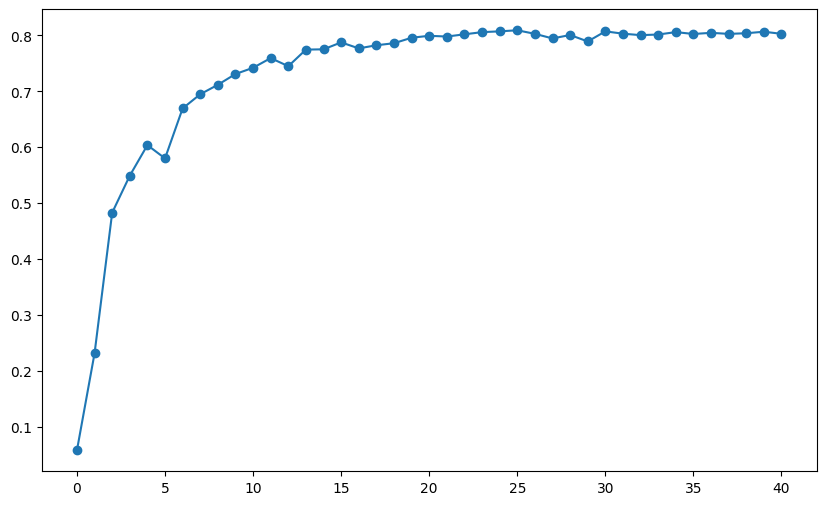

In [9]:
results_list = [
    results_bce,
    results_dice,
    results_bce_dice,
    results_tversky
]
labels_list = [
    "BCE",
    "Dice",
    "BCE + Dice",
    "Tversky"
]
evaluate_losses(results_list, labels_list)